# Proyek Analisis Data: [E-commerce public dataset]
- **Nama:** Arifah Anggraini Nukuhehe
- **Email:** arifahanggraini05@gmail.com
- **ID Dicoding:** arifah_anggraini__si9x

## Menentukan Pertanyaan Bisnis

- Bagaimana tren total penyewaan sepeda dari tahun 2011 ke 2012 ?
- Bagaimana pengaruh musim dan cuaca terhadap jumlah penyewaan sepeda ?
- Jam berapa saja dalam sehari yang menjadi puncak penyewaan sepedapaling tinggi dan paling rendah ?

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [2]:
day_df = pd.read_csv("day.csv")
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- Kode di atas menampilkan 5 baris pertama dari dataframe day_df

In [3]:
hour_df = pd.read_csv("hour.csv")
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Kode di atas menghasilkan 5 baris data pertama dari dataframe hour_df

### Assessing Data

In [4]:
day_df.info()
print("jumlah data kosong: ", day_df.isna().sum())
print("Jumlah duplikasi: ", day_df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
jumlah data kosong:  instant       0
dteday        0
season        0
yr            0
mnth    

**Insight:**
- Tidak ada data yang kosong dan tidak ada juga data yang duplikat.
- Tipe data kolom dteday berupa objek akan diganti menjadi datetime untuk mengambil data hari saja.
- Melakukan mapping pada kolom season, weathersit, weekday dan weekday yang bertipe data integer supaya dapat dibaca saat melakukan visualisasi.

In [5]:
hour_df.info()
print("Jumlah data kosong: ", hour_df.isna().sum())
print("Jumlah duplikasi: ", hour_df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB
Jumlah data kosong:  instant       0
dteday      

**Insight:**
- tidak ada data yang kosong dan tidak ada data yang duplikat.
- tipe data dteday berupa object akan diganti menjadi datetime untuk mengambil data jam saja.
- Melakukan mapping pada kolom season, weathersit, weekday dan year yang bertipe data integer supaya dapat dibaca saat melakukan visualisasi.
- Melakukan normalisasi pada kolom temp dan atemp supaya kembali dalam satuan celsius

### Cleaning Data

In [6]:
from pandas.core.frame import DataFrame
#Mengubah tipe data dteday menjadi datetime pada data day dan hour.
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

#Mapping label kategorikal
season_mapping = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weather_mapping = {1: 'clear', 2: 'misty/cloudy', 3: 'light rain/light snow', 4: 'heavy rain/ heavy snow'}
weekday_mapping = {0: 'sunday', 1:'monday', 2:'tuesday', 3:'wednesday', 4:'thursday', 5:'friday', 6:'saturday'}
year_mapping = {0: 2011, 1: 2012}

for df in [day_df, hour_df]:
    df['season_label']  = df['season'].map(season_mapping)
    df['weather_label'] = df['weathersit'].map(weather_mapping)
    df['year_label']    = df['yr'].map(year_mapping)
    df['weekday_label'] = df['weekday'].map(weekday_mapping)
    # 4. Denormalisasi suhu ke Celsius
    df['temp_c']        = df['temp'] * 41
    df['atemp_c']       = df['atemp'] * 50

print(f'Rentang suhu aktual: {day_df["temp_c"].min():.1f}°C — {day_df["temp_c"].max():.1f}°C')
display(day_df[['dteday','season_label','weather_label','temp_c','cnt']].head())


Rentang suhu aktual: 2.4°C — 35.3°C


,dteday,season_label,weather_label,temp_c,cnt
0,2011-01-01,Spring,misty/cloudy,14.110847,985
1,2011-01-02,Spring,misty/cloudy,14.902598,801
2,2011-01-03,Spring,clear,8.050924,1349
3,2011-01-04,Spring,clear,8.200000,1562
4,2011-01-05,Spring,clear,9.305237,1600


**Insight:**
- Mengkonversi tipe data dteday yang tadinya objek menjadi datetime supaya bisa menganalisis berdasarkan waktu tertentu.
- Melakukan mapping label kategorikal supaya lebih jelas dalam visualisasi
- Denormalisasi suhu (mengembalikan suhu menjadi satuan derajat celsius)

## Exploratory Data Analysis (EDA)

### Explore Data Day

In [7]:
# Melihat rangkuman parameter statistik data day
day_df.describe(include='all')

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,...,windspeed,casual,registered,cnt,season_label,weather_label,year_label,weekday_label,temp_c,atemp_c
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,...,731.000000,731.000000,731.000000,731.000000,731,731,731.000000,731,731.000000,731.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,4,3,NaN,7,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Fall,clear,NaN,saturday,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,188,463,NaN,105,NaN,NaN
mean,366.000000,2012-01-01 00:00:00,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,...,0.190486,848.176471,3656.172367,4504.348837,NaN,NaN,2011.500684,NaN,20.310776,23.717699
min,1.000000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,...,0.022392,2.000000,20.000000,22.000000,NaN,NaN,2011.000000,NaN,2.424346,3.953480
25%,183.500000,2011-07-02 12:00:00,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,...,0.134950,315.500000,2497.000000,3152.000000,NaN,NaN,2011.000000,NaN,13.820424,16.892125
50%,366.000000,2012-01-01 00:00:00,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,...,0.180975,713.000000,3662.000000,4548.000000,NaN,NaN,2012.000000,NaN,20.431653,24.336650
75%,548.500000,2012-07-01 12:00:00,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,...,0.233214,1096.000000,4776.500000,5956.000000,NaN,NaN,2012.000000,NaN,26.872076,30.430100
max,731.000000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,...,0.507463,3410.000000,6946.000000,8714.000000,NaN,NaN,2012.000000,NaN,35.328347,42.044800


In [8]:
# Eksplor data hour
hour_df.describe(include='all')

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,...,windspeed,casual,registered,cnt,season_label,weather_label,year_label,weekday_label,temp_c,atemp_c
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,...,17379.000000,17379.000000,17379.000000,17379.000000,17379,17379,17379.000000,17379,17379.000000,17379.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,4,4,NaN,7,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Fall,clear,NaN,saturday,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,4496,11413,NaN,2512,NaN,NaN
mean,8690.0000,2012-01-02 04:08:34.552045568,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,...,0.190098,35.676218,153.786869,189.463088,NaN,NaN,2011.502561,NaN,20.376474,23.788755
min,1.0000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,1.000000,NaN,NaN,2011.000000,NaN,0.820000,0.000000
25%,4345.5000,2011-07-04 00:00:00,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,...,0.104500,4.000000,34.000000,40.000000,NaN,NaN,2011.000000,NaN,13.940000,16.665000
50%,8690.0000,2012-01-02 00:00:00,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,...,0.194000,17.000000,115.000000,142.000000,NaN,NaN,2012.000000,NaN,20.500000,24.240000
75%,13034.5000,2012-07-02 00:00:00,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,...,0.253700,48.000000,220.000000,281.000000,NaN,NaN,2012.000000,NaN,27.060000,31.060000
max,17379.0000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,...,0.850700,367.000000,886.000000,977.000000,NaN,NaN,2012.000000,NaN,41.000000,50.000000


In [9]:
#Melihat Tren Penyewaan tahun 2011 dan 2012
tren = day_df.groupby(by='yr')['cnt'].agg(
    ['sum', 'mean', 'max', 'min']
)
tren.index = [2011, 2012]
tren.columns = ['Jumlah', 'Rata-Rata/Hari', 'Maksimal Penyewaan/Hari', 'Minimal Penyewaan/Hari']

growth = (tren.loc[2012, 'Jumlah'] - tren.loc[2011, 'Jumlah']) / tren.loc[2011, 'Jumlah'] * 100

display(tren.style.format('{:,.0f}'))
print(f'\n📈 Pertumbuhan total 2011→2012: +{growth:.1f}%')



,Jumlah,Rata-Rata/Hari,Maksimal Penyewaan/Hari,Minimal Penyewaan/Hari
2011,"1,243,103","3,406","6,043",431
2012,"2,049,576","5,600","8,714",22



📈 Pertumbuhan total 2011→2012: +64.9%


In [10]:
# Melihat pengaruh musim dan cuaca pada jumlah penyewaan
season_order = ['Spring','Summer','Fall','Winter']
season_stats = day_df.groupby('season_label')['cnt'].agg(['mean','sum'])
season_stats = season_stats.reindex(season_order)
print('=== Per Musim ===')
display(season_stats.round(0))

weather_stats = day_df.groupby('weathersit')['cnt'].agg(['mean','count'])
print('\n=== Per Kondisi Cuaca ===')
display(weather_stats.sort_values('mean', ascending=False).round(0))

=== Per Musim ===


,mean,sum
season_label,,
Spring,2604.0,471348
Summer,4992.0,918589
Fall,5644.0,1061129
Winter,4728.0,841613



=== Per Kondisi Cuaca ===


,mean,count
weathersit,,
1,4877.0,463
2,4036.0,247
3,1803.0,21


In [12]:
#Lihat Parameter Statistik data hour
hour_df.describe(include='all')

# Melihat 5 Jam penyewaan tertinggi dan 5 penyewaan terendah
# ── Q3: Pola per jam ──
hourly = hour_df.groupby('hr')['cnt'].mean().reset_index()
hourly.columns = ['Jam','Rata-rata']
print('Top 5 jam tersibuk:')
display(hourly.sort_values('Rata-rata', ascending=False).head(5))
print('\nTop 5 jam tersenyap:')
display(hourly.sort_values('Rata-rata').head(5))

Top 5 jam tersibuk:


,Jam,Rata-rata
17,17,461.452055
18,18,425.510989
8,8,359.011004
16,16,311.983562
19,19,311.523352



Top 5 jam tersenyap:


,Jam,Rata-rata
4,4,6.352941
3,3,11.727403
5,5,19.889819
2,2,22.869930
1,1,33.375691


**Insight:**
- Penyewaan sepeda bertambah sebesar 64.9%
- Musim berkolerasi positif dengan jumlah penyewaan dan cuaca berkolerasi negatif dengan jumlah penyewaan
- Puncak Penyewaan Terjadi pada jam 17.00 dengan 461 sebagai rata-rata penyewaan. Sedangkan Penyewaan Tersenyap terjadi pada jam 4.00 dengan 6 sebagai nilai rata-rata penyewaan.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana tren total penyewaan sepeda dari tahun 2011 ke 2012 ?

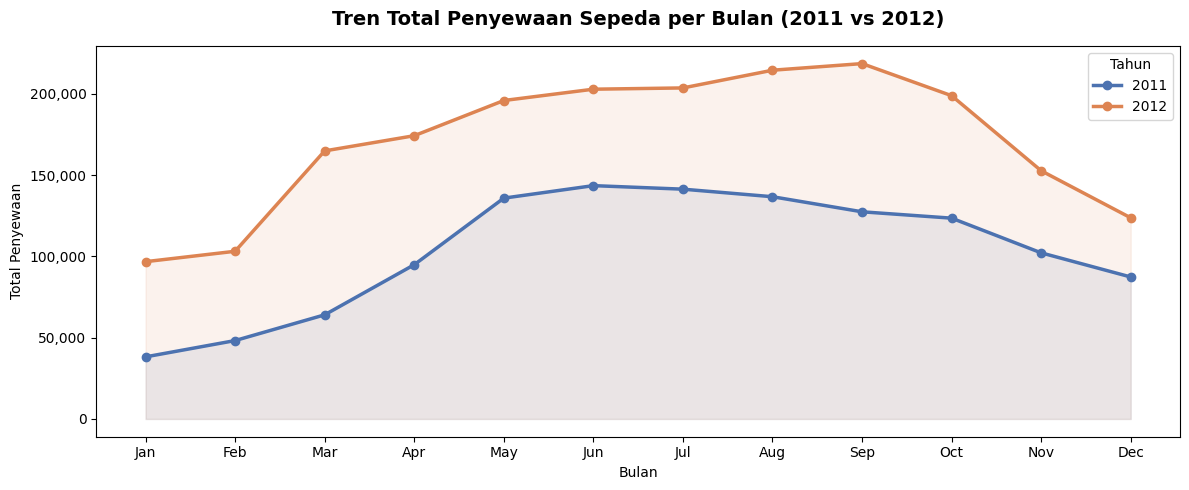

In [13]:
monthly = day_df.groupby(['year_label','mnth'])['cnt'].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
colors = {2011:'#4C72B0', 2012:'#DD8452'}
for yr, grp in monthly.groupby('year_label'):
    ax.plot(grp['mnth'], grp['cnt'], marker='o', lw=2.5, color=colors[yr], label=str(yr))
    ax.fill_between(grp['mnth'], grp['cnt'], alpha=0.1, color=colors[yr])

ax.set_xticks(range(1,13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.set_title('Tren Total Penyewaan Sepeda per Bulan (2011 vs 2012)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Bulan'); ax.set_ylabel('Total Penyewaan')
ax.legend(title='Tahun')
plt.tight_layout()
plt.savefig('viz1_tren_bulanan.png', bbox_inches='tight')
plt.show()

### Pertanyaan 2: Bagaimana Pengaruh musim dan cuaca terhadap jumlah penyewaan sepeda ?

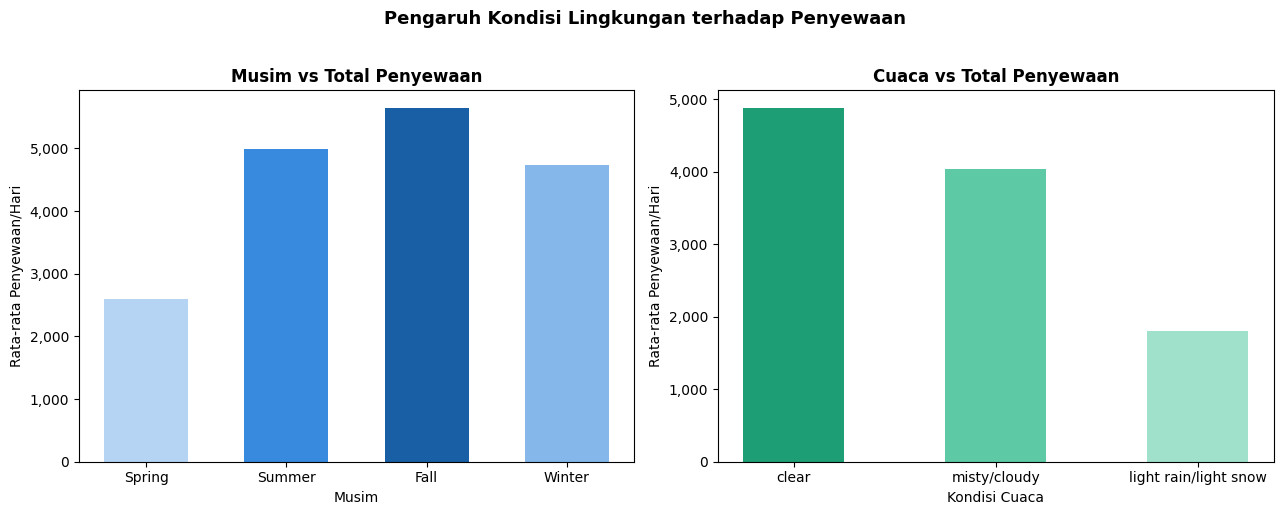

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Chart 1 — Per Musim
season_order = ['Spring', 'Summer', 'Fall', 'Winter']
season_stats = day_df.groupby('season_label')['cnt'].mean().reindex(season_order)
colors_season = ['#b5d4f4', '#378add', '#185fa5', '#85b7eb']

axes[0].bar(season_stats.index, season_stats.values, color=colors_season, edgecolor='none', width=0.6)
axes[0].set_title('Musim vs Total Penyewaan', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Musim')
axes[0].set_ylabel('Rata-rata Penyewaan/Hari')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Chart 2 — Per Cuaca
weather_order = ['clear', 'misty/cloudy', 'light rain/light snow']
weather_stats = day_df.groupby('weather_label')['cnt'].mean().reindex(weather_order)
colors_weather = ['#1d9e75', '#5dcaa5', '#9fe1cb']

axes[1].bar(weather_stats.index, weather_stats.values, color=colors_weather, edgecolor='none', width=0.5)
axes[1].set_title('Cuaca vs Total Penyewaan', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Kondisi Cuaca')
axes[1].set_ylabel('Rata-rata Penyewaan/Hari')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Pengaruh Kondisi Lingkungan terhadap Penyewaan', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz5_musim_cuaca.png', bbox_inches='tight')
plt.show()

### Pertanyaan 3: Pada jam berapa terjadinya puncak penyewaan sepeda dan terendah dalam sehari ?

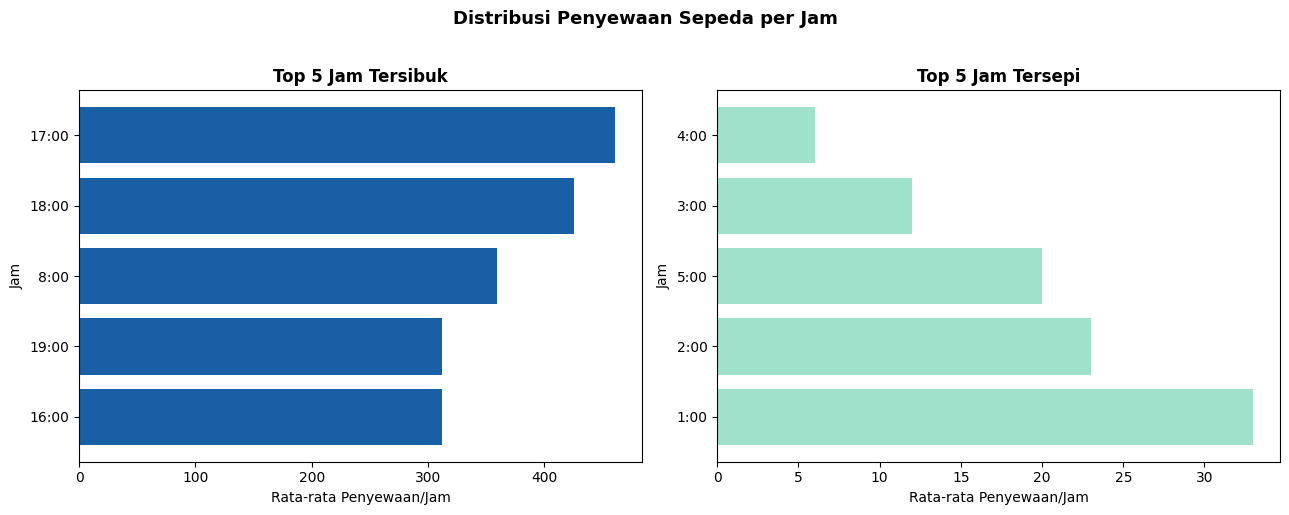

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

hourly = hour_df.groupby('hr')['cnt'].mean().round(0)

# Top 5 jam tersibuk
top5 = hourly.nlargest(5).sort_values(ascending=True)
axes[0].barh(top5.index.astype(str) + ':00', top5.values, color='#185fa5', edgecolor='none')
axes[0].set_title('Top 5 Jam Tersibuk', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Rata-rata Penyewaan/Jam')
axes[0].set_ylabel('Jam')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Top 5 jam tersepi
bot5 = hourly.nsmallest(5).sort_values(ascending=False)
axes[1].barh(bot5.index.astype(str) + ':00', bot5.values, color='#9fe1cb', edgecolor='none')
axes[1].set_title('Top 5 Jam Tersepi', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Rata-rata Penyewaan/Jam')
axes[1].set_ylabel('Jam')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Distribusi Penyewaan Sepeda per Jam', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_jam_sibuk_sepi.png', bbox_inches='tight')
plt.show()

**Insight:**
**Insight:**

**Visualisasi 1 — Tren Penyewaan 2011 vs 2012:**
- Penyewaan sepeda mengalami pertumbuhan signifikan sebesar 64.9% dari tahun 2011 ke 2012
- Kedua tahun menunjukkan pola musiman yang serupa — meningkat di pertengahan tahun dan menurun di akhir tahun
- Puncak penyewaan tertinggi terjadi pada bulan Juni–September di kedua tahun, bertepatan dengan musim panas dan gugur

**Visualisasi 2 — Pengaruh Musim dan Cuaca:**
- Musim Fall (Gugur) mencatat rata-rata penyewaan tertinggi, diikuti Summer (Panas), Winter (Dingin), dan Spring (Semi)
- Musim Spring memiliki penyewaan terendah, kemungkinan karena cuaca yang masih tidak menentu di awal tahun
- Cuaca cerah (clear) menghasilkan penyewaan jauh lebih tinggi dibanding kondisi lainnya
- Hujan/salju ringan drastis menurunkan jumlah penyewaan, menunjukkan pengguna sangat sensitif terhadap cuaca buruk

**Visualisasi 3 — Distribusi Penyewaan per Jam:**
- Puncak penyewaan tertinggi terjadi pada jam 17:00 dan 18:00, bertepatan dengan jam pulang kerja
- Jam 08:00 juga masuk top 5, menunjukkan adanya pola commuter berangkat dan pulang kerja
- Penyewaan terendah terjadi dini hari antara jam 02:00–05:00 saat aktivitas hampir tidak ada
- Pola ini mengindikasikan sebagian besar pengguna menyewa sepeda untuk keperluan komuter harian, bukan sekadar rekreasi

## Analisis Lanjutan (Opsional)

## Conclusion

- Terjadi pertumbuhan sebesar 64.9% penyewaan sepeda dari tahun 2011 ke tahun 2012
-  Penyewaan tertinggi terjadi pada musim gugur dan cuaca cerah, sedangkan penyewaan terendah terjadi pada musim semi dan cuaca hujan/salju
- Puncak Teramai penyewaan sepeda terjadi pada jam 17.00 dan penyewaan tersepi terjadi pada 4.00